In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
apple = pd.read_csv('../Yahoo_Finance/Apple/AAPL_historical_stock.csv')
apple

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098207,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093083,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086251,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.088386,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.090949,73449600
...,...,...,...,...,...,...,...
11497,2026-07-29,339.730011,344.570007,337.350006,338.190002,338.190002,56090800
11498,2026-07-30,333.100006,334.750000,329.589996,333.429993,333.429993,74817800
11499,2026-07-31,304.809998,310.690002,300.000000,308.910004,308.910004,132489100
11500,2026-08-03,309.579987,311.799988,302.559998,303.420013,303.420013,74824300


In [3]:
# apple['Date'] = apple['Date'].str.extract(r'(\d{4}-\d{1,2})')
# apple

apple['observation_month'] = apple['Date'].str[:-3]
apple

,Date,Open,High,Low,Close,Adj Close,Volume,observation_month
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098207,469033600,1980-12
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093083,175884800,1980-12
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086251,105728000,1980-12
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.088386,86441600,1980-12
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.090949,73449600,1980-12
...,...,...,...,...,...,...,...,...
11497,2026-07-29,339.730011,344.570007,337.350006,338.190002,338.190002,56090800,2026-07
11498,2026-07-30,333.100006,334.750000,329.589996,333.429993,333.429993,74817800,2026-07
11499,2026-07-31,304.809998,310.690002,300.000000,308.910004,308.910004,132489100,2026-07
11500,2026-08-03,309.579987,311.799988,302.559998,303.420013,303.420013,74824300,2026-08


In [4]:
apple.dtypes

Date                     str
Open                 float64
High                 float64
Low                  float64
Close                float64
Adj Close            float64
Volume                 int64
observation_month        str
dtype: object

In [5]:
inflation = pd.read_csv('../FRED/inflation.csv')
inflation

,observation_date,CPIAUCSL
0,1947-01-01,21.480
1,1947-02-01,21.620
2,1947-03-01,22.000
3,1947-04-01,22.000
4,1947-05-01,21.950
...,...,...
949,2026-02-01,327.460
950,2026-03-01,330.293
951,2026-04-01,332.407
952,2026-05-01,333.979


In [6]:
inflation['observation_date'] = inflation['observation_date'].str[:-3]
inflation

,observation_date,CPIAUCSL
0,1947-01,21.480
1,1947-02,21.620
2,1947-03,22.000
3,1947-04,22.000
4,1947-05,21.950
...,...,...
949,2026-02,327.460
950,2026-03,330.293
951,2026-04,332.407
952,2026-05,333.979


In [7]:
inflation.isna().value_counts()

observation_date  CPIAUCSL
False             False       953
                  True          1
Name: count, dtype: int64

In [8]:
# inflation.dropna()

In [9]:
# apple['Date'] = pd.to_datetime(apple['Date']).dt.strftime('%Y-%m')
# inflation['Date'] = pd.to_datetime(inflation['Date']).dt.strftime('%Y-%m')


# inflation = inflation.rename(columns={'observation_date': 'Date'})
# merged = pd.merge(apple, inflation, on='Date', how='inner')


In [10]:
# inflation['observation_date'] = inflation['observation_date'].str[:-3]
# apple

In [11]:
# apple['Month'] = apple['Date'].str[5:-3]
# apple

In [12]:
df = pd.merge(apple, inflation, left_on='observation_month', right_on='observation_date')
df

,Date,Open,High,Low,Close,Adj Close,Volume,observation_month,observation_date,CPIAUCSL
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098207,469033600,1980-12,1980-12,86.400
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093083,175884800,1980-12,1980-12,86.400
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086251,105728000,1980-12,1980-12,86.400
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.088386,86441600,1980-12,1980-12,86.400
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.090949,73449600,1980-12,1980-12,86.400
...,...,...,...,...,...,...,...,...,...,...
11473,2026-06-24,295.359985,299.700012,292.940002,293.079987,293.079987,53081900,2026-06,2026-06,332.568
11474,2026-06-25,287.399994,288.799988,273.750000,275.149994,275.149994,107013700,2026-06,2026-06,332.568
11475,2026-06-26,275.000000,285.950012,274.209991,283.779999,283.779999,261775500,2026-06,2026-06,332.568
11476,2026-06-29,286.730011,288.369995,279.850006,281.739990,281.739990,66427000,2026-06,2026-06,332.568


In [13]:
df = df[df['CPIAUCSL'].notna()]

<Axes: xlabel='Close', ylabel='CPIAUCSL'>

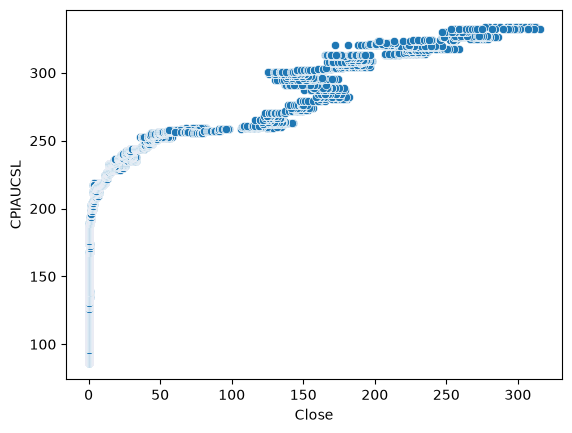

In [14]:
sns.scatterplot(data=df, x= 'Close', y='CPIAUCSL')

In [15]:
df_1 = df[['Close', 'CPIAUCSL']]
df_1

,Close,CPIAUCSL
0,0.128348,86.400
1,0.121652,86.400
2,0.112723,86.400
3,0.115513,86.400
4,0.118862,86.400
...,...,...
11473,293.079987,332.568
11474,275.149994,332.568
11475,283.779999,332.568
11476,281.739990,332.568


In [16]:
df_1.corr()

,Close,CPIAUCSL
Close,1.000000,0.772256
CPIAUCSL,0.772256,1.000000


In [17]:
df['CPIAUCSL'].isna().value_counts()

CPIAUCSL
False    11455
Name: count, dtype: int64

In [18]:
# seprating training and testing
X_train, X_test, y_train, y_test = train_test_split(df[['Close']], df['CPIAUCSL'], test_size=0.2, random_state=42)
y_train.shape

(9164,)

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.78]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Close']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,166.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


RMSE: 40.56
MAE:  34.90
R^2:  0.586


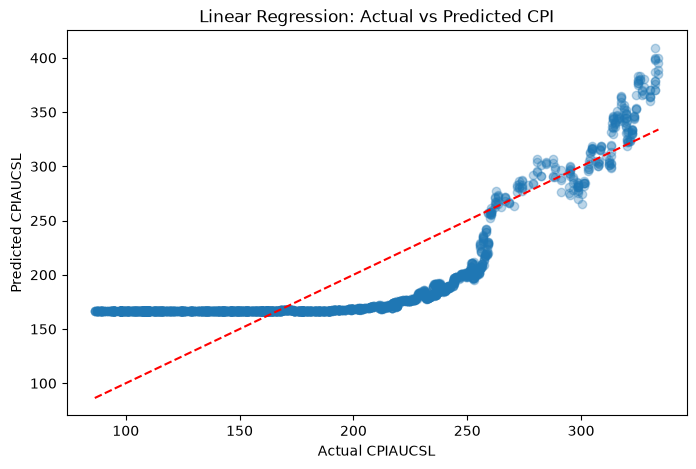

In [20]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R^2:  {r2:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel('Actual CPIAUCSL')
plt.ylabel('Predicted CPIAUCSL')
plt.title('Linear Regression: Actual vs Predicted CPI')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()